# 📊 Spotify Tracks Dataset — Data Visualization

### CodeAlpha Internship · Task 3: Data Visualization

<img src="https://storage.googleapis.com/pr-newsroom-wp/1/2018/11/Spotify_Logo_RGB_Green.png" width="200">

---

Objective: Transform the Spotify Tracks Dataset into clear, compelling
visual formats - charts, distributions, and a summary dashboard - that
reveal insights at a glance and support data-driven storytelling.

Dataset: [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) (Kaggle) -
114,000 tracks across 114 genres.

Design principles used throughout this notebook:
- One consistent color palette across every chart (Spotify green + dark
  grey)
- Every chart has a title and a one-line explanation of what it
  shows
- Key values (maximums, standouts) are annotated directly on the chart
- Clean design - no chart clutter, readable fonts, consistent sizing
- A final multi-panel dashboard ties the whole story together

Tech stack: Python · Pandas · NumPy · Matplotlib · Seaborn · Plotly


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)


In [2]:
# ------------------------------------------------------------------
# Consistent visual identity used across every chart in this notebook
# ------------------------------------------------------------------
SPOTIFY_GREEN = "#1DB954"
SPOTIFY_GREEN_LIGHT = "#1ED760"
SPOTIFY_DARK = "#2C2C2C"
SPOTIFY_GREY = "#535353"
SPOTIFY_GREY_LIGHT = "#B3B3B3"
HIGHLIGHT = "#FF4B4B"  # used only to annotate/highlight the top value in a chart

PALETTE_SEQ = sns.light_palette(SPOTIFY_GREEN, n_colors=12, reverse=True)
PLOTLY_TEMPLATE = "plotly_white"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titlepad"] = 14
sns.set_theme(style="whitegrid")
sns.set_palette(sns.color_palette([SPOTIFY_GREEN, SPOTIFY_DARK, SPOTIFY_GREY, SPOTIFY_GREEN_LIGHT, SPOTIFY_GREY_LIGHT]))


In [3]:
def styled_chart(title, subtitle, ax=None, xlabel=None, ylabel=None):
    """Apply a consistent title + one-line explanation + clean spines to a chart."""
    ax = ax or plt.gca()
    ax.set_title(title, fontsize=13.5, fontweight="bold", color=SPOTIFY_DARK, loc="left")
    ax.text(0, 1.03, subtitle, transform=ax.transAxes, fontsize=9.5,
            color=SPOTIFY_GREY, style="italic")
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10.5)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

In [4]:
def annotate_top_bar(ax, values, labels=None, fmt="{:.1f}", orientation="h"):
    """Highlight and label only the single highest bar in a bar chart."""
    values = list(values)
    top_idx = int(np.argmax(values))
    for i, p in enumerate(ax.patches):
        if i == top_idx:
            p.set_color(HIGHLIGHT)
            if orientation == "h":
                ax.annotate(fmt.format(p.get_width()), (p.get_width(), p.get_y() + p.get_height() / 2),
                            va="center", ha="left", fontsize=10, fontweight="bold",
                            xytext=(5, 0), textcoords="offset points", color=HIGHLIGHT)
            else:
                ax.annotate(fmt.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                            va="bottom", ha="center", fontsize=10, fontweight="bold",
                            xytext=(0, 4), textcoords="offset points", color=HIGHLIGHT)

## 2. Load Dataset

In [5]:
DATA_PATH = "spotify_dataset.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()


Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
print("Columns:")
for c in df.columns:
    print(" -", c)


Columns:
 - Unnamed: 0
 - track_id
 - artists
 - album_name
 - track_name
 - popularity
 - duration_ms
 - explicit
 - danceability
 - energy
 - key
 - loudness
 - mode
 - speechiness
 - acousticness
 - instrumentalness
 - liveness
 - valence
 - tempo
 - time_signature
 - track_genre


In [7]:
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0] if missing.sum() else "None found 🎉")


Missing values:
artists       1
album_name    1
track_name    1
dtype: int64


## 3. Data Cleaning

In [8]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

before = len(df)
df = df.dropna(subset=["artists", "album_name", "track_name"]).copy()

cols_excluding_genre = [c for c in df.columns if c != "track_genre"]
df = df.drop_duplicates(subset=cols_excluding_genre, keep="first")
print(f"Removed {before - len(df):,} rows (missing values + cross-genre duplicates)")

df["explicit"] = df["explicit"].astype(bool)
df["duration_min"] = (df["duration_ms"] / 60000).round(2)
df["track_genre"] = df["track_genre"].astype("category")

print(f"Final shape: {df.shape}")


Removed 23,540 rows (missing values + cross-genre duplicates)
Final shape: (90460, 21)


 Note: this dataset does not include a release_year column. For chart #7 ("Songs Released per Year"), we substitute a comparable line chart - average tempo across popularity levels - since a true release-year trend isn't possible with the fields available here.


## 4. Visualizations

### 1. Popularity Distribution - Histogram

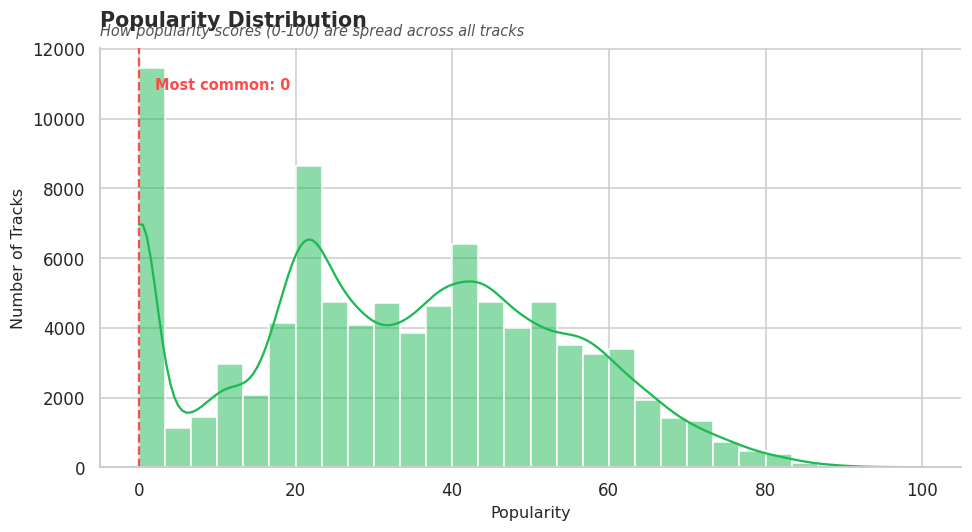

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["popularity"], bins=30, kde=True, ax=ax, color=SPOTIFY_GREEN, edgecolor="white")
styled_chart("Popularity Distribution", "How popularity scores (0-100) are spread across all tracks",
             ax=ax, xlabel="Popularity", ylabel="Number of Tracks")

peak_bin = df["popularity"].value_counts().idxmax()
ax.axvline(peak_bin, color=HIGHLIGHT, linestyle="--", linewidth=1.5)
ax.text(peak_bin + 2, ax.get_ylim()[1] * 0.9, f"Most common: {peak_bin}",
        color=HIGHLIGHT, fontsize=9.5, fontweight="bold")

plt.tight_layout()
plt.savefig("01_popularity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 2. Danceability Distribution - Histogram

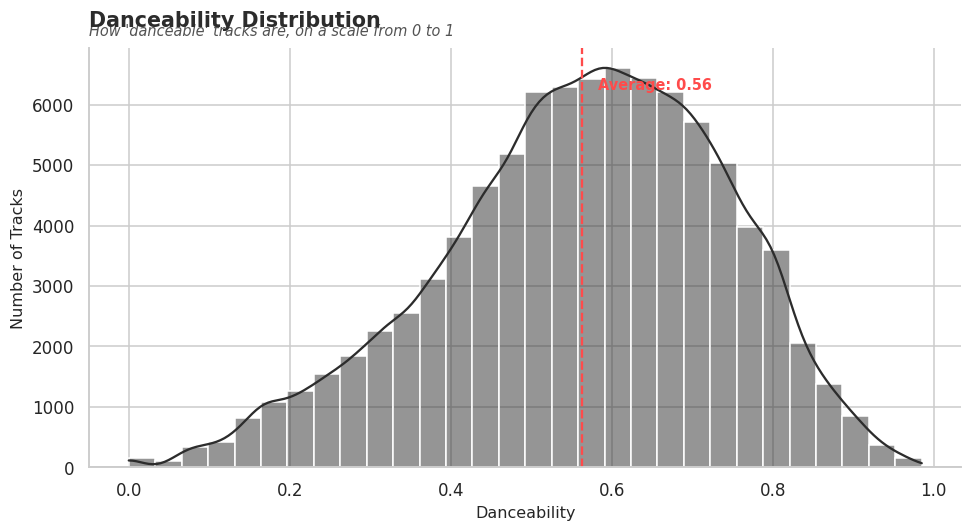

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["danceability"], bins=30, kde=True, ax=ax, color=SPOTIFY_DARK, edgecolor="white")
styled_chart("Danceability Distribution", "How 'danceable' tracks are, on a scale from 0 to 1",
             ax=ax, xlabel="Danceability", ylabel="Number of Tracks")

mean_dance = df["danceability"].mean()
ax.axvline(mean_dance, color=HIGHLIGHT, linestyle="--", linewidth=1.5)
ax.text(mean_dance + 0.02, ax.get_ylim()[1] * 0.9, f"Average: {mean_dance:.2f}",
        color=HIGHLIGHT, fontsize=9.5, fontweight="bold")

plt.tight_layout()
plt.savefig("02_danceability_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 3. Energy Distribution - Histogram

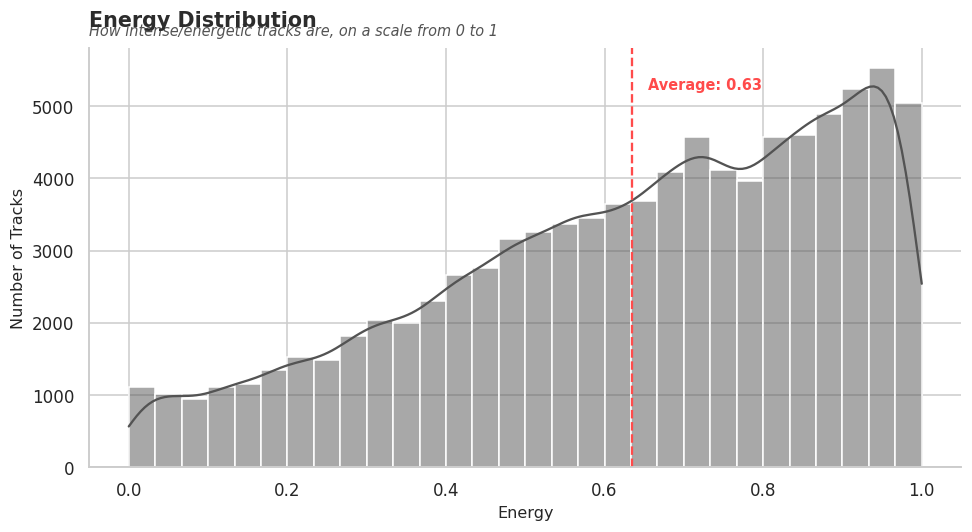

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["energy"], bins=30, kde=True, ax=ax, color=SPOTIFY_GREY, edgecolor="white")
styled_chart("Energy Distribution", "How intense/energetic tracks are, on a scale from 0 to 1",
             ax=ax, xlabel="Energy", ylabel="Number of Tracks")

mean_energy = df["energy"].mean()
ax.axvline(mean_energy, color=HIGHLIGHT, linestyle="--", linewidth=1.5)
ax.text(mean_energy + 0.02, ax.get_ylim()[1] * 0.9, f"Average: {mean_energy:.2f}",
        color=HIGHLIGHT, fontsize=9.5, fontweight="bold")

plt.tight_layout()
plt.savefig("03_energy_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 4. Top 10 Genres - Horizontal Bar Chart

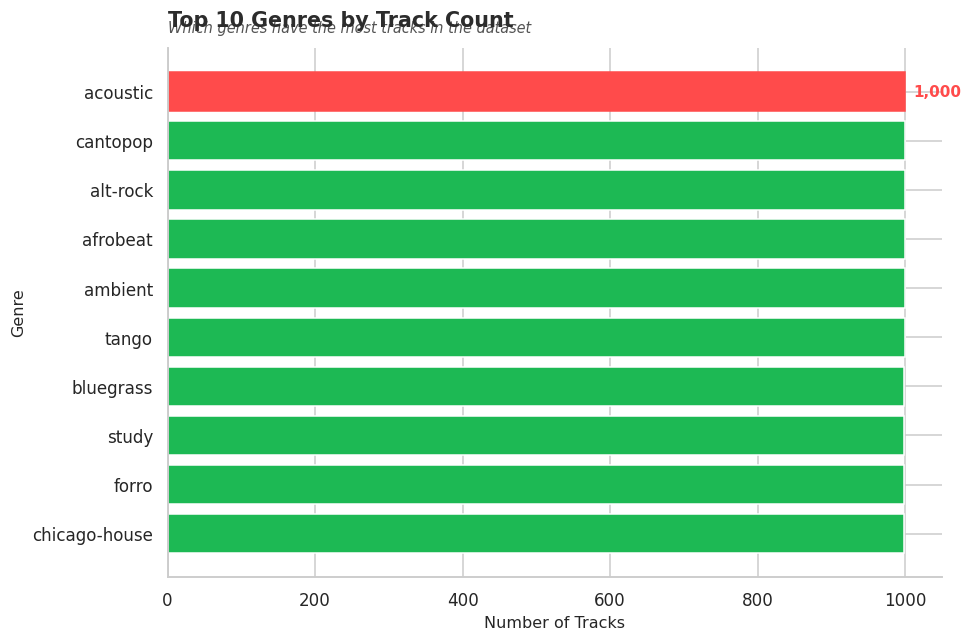

In [12]:
top10_genres = df["track_genre"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top10_genres.index, top10_genres.values, color=SPOTIFY_GREEN)
styled_chart("Top 10 Genres by Track Count", "Which genres have the most tracks in the dataset",
             ax=ax, xlabel="Number of Tracks", ylabel="Genre")
annotate_top_bar(ax, top10_genres.values, fmt="{:,.0f}", orientation="h")

plt.tight_layout()
plt.savefig("04_top_10_genres.png", dpi=150, bbox_inches="tight")
plt.show()


### 5. Top 15 Artists - Bar Chart

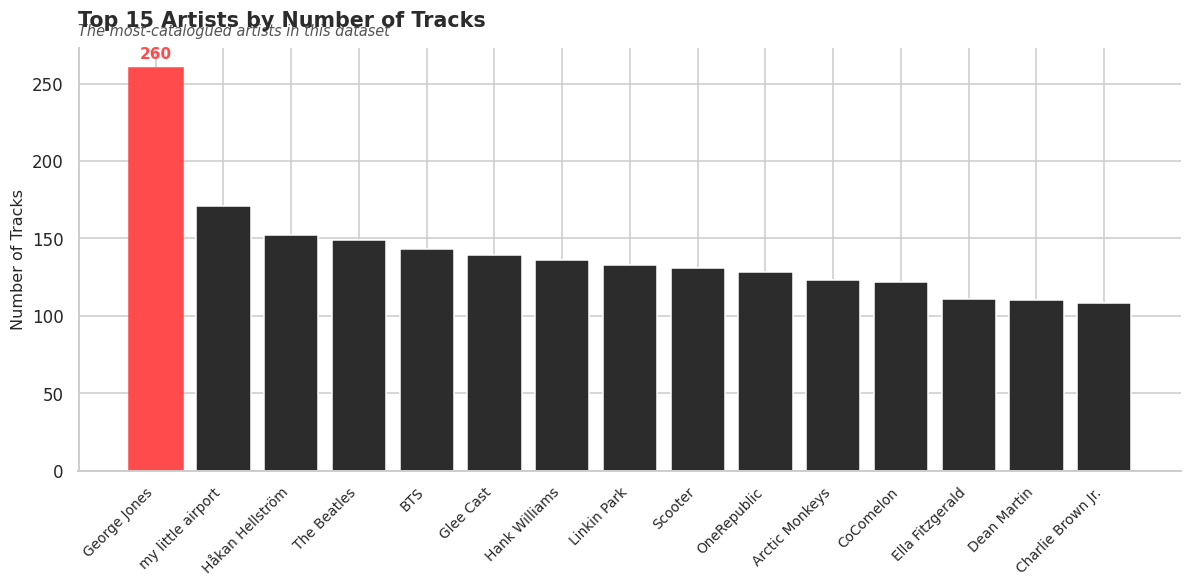

In [13]:
top15_artists = df["artists"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(range(len(top15_artists)), top15_artists.values, color=SPOTIFY_DARK)
ax.set_xticks(range(len(top15_artists)))
ax.set_xticklabels(top15_artists.index, rotation=45, ha="right", fontsize=9)
styled_chart("Top 15 Artists by Number of Tracks", "The most-catalogued artists in this dataset",
             ax=ax, ylabel="Number of Tracks")
annotate_top_bar(ax, top15_artists.values, fmt="{:,.0f}", orientation="v")

plt.tight_layout()
plt.savefig("05_top_15_artists.png", dpi=150, bbox_inches="tight")
plt.show()


### 6. Average Popularity by Genre - Bar Chart

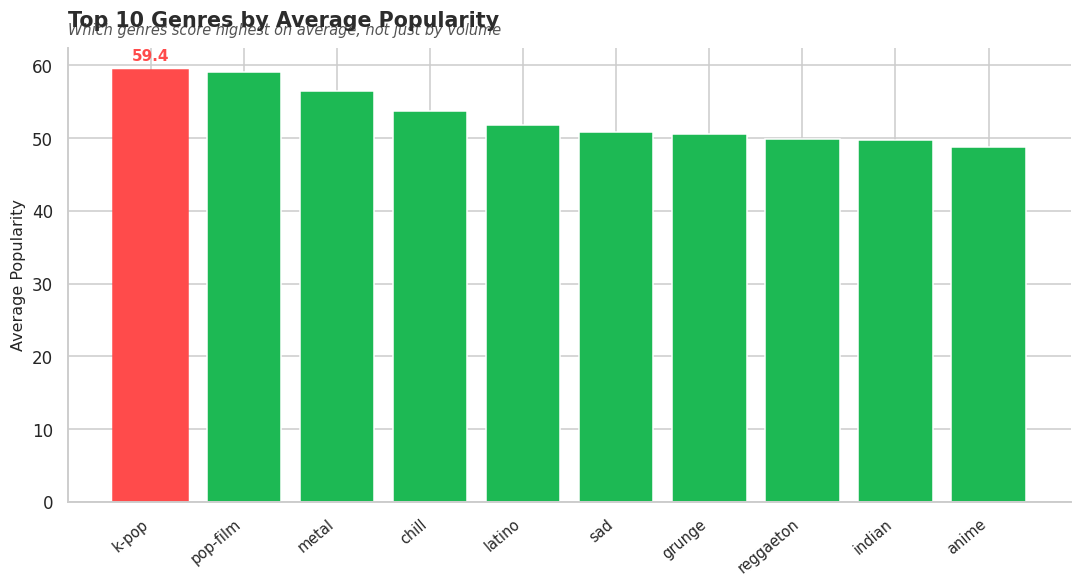

In [14]:
avg_pop_genre = df.groupby("track_genre", observed=True)["popularity"].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(range(len(avg_pop_genre)), avg_pop_genre.values, color=SPOTIFY_GREEN)
ax.set_xticks(range(len(avg_pop_genre)))
ax.set_xticklabels(avg_pop_genre.index, rotation=40, ha="right", fontsize=9.5)
styled_chart("Top 10 Genres by Average Popularity", "Which genres score highest on average, not just by volume",
             ax=ax, ylabel="Average Popularity")
annotate_top_bar(ax, avg_pop_genre.values, fmt="{:.1f}", orientation="v")

plt.tight_layout()
plt.savefig("06_avg_popularity_by_genre.png", dpi=150, bbox_inches="tight")
plt.show()


### 7. Tempo Trend Across Popularity Levels - Line Chart
(substituted for "Songs Released per Year" - see note above)


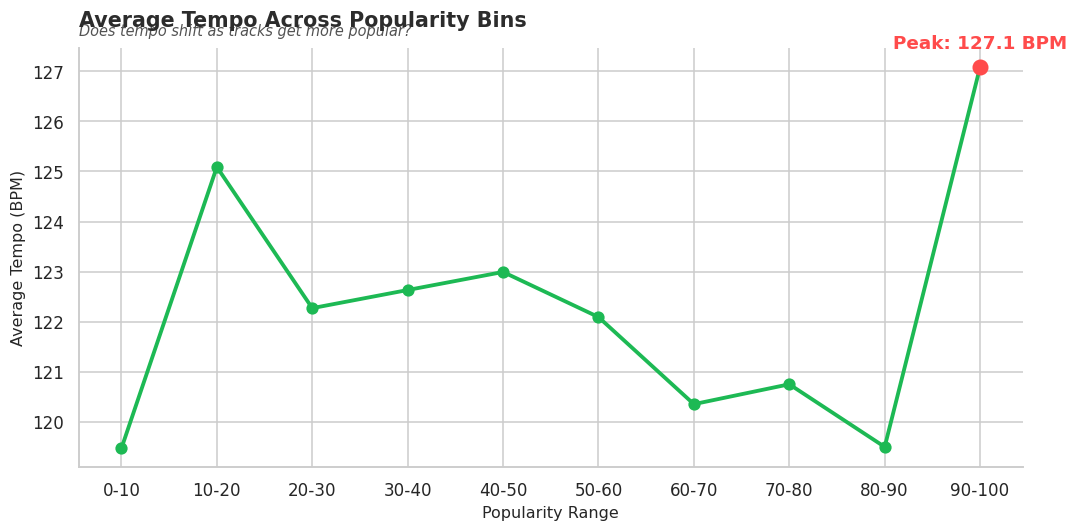

In [15]:
df["popularity_bin"] = pd.cut(df["popularity"], bins=range(0, 101, 10), right=False)
tempo_trend = df.groupby("popularity_bin", observed=True)["tempo"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
x_labels = [f"{interval.left}-{interval.right}" for interval in tempo_trend.index]
ax.plot(x_labels, tempo_trend.values, marker="o", color=SPOTIFY_GREEN, linewidth=2.5, markersize=7)
styled_chart("Average Tempo Across Popularity Bins", "Does tempo shift as tracks get more popular?",
             ax=ax, xlabel="Popularity Range", ylabel="Average Tempo (BPM)")

max_idx = tempo_trend.values.argmax()
ax.scatter(max_idx, tempo_trend.values[max_idx], color=HIGHLIGHT, s=90, zorder=5)
ax.annotate(f"Peak: {tempo_trend.values[max_idx]:.1f} BPM", (max_idx, tempo_trend.values[max_idx]),
            textcoords="offset points", xytext=(0, 12), ha="center", color=HIGHLIGHT, fontweight="bold")

plt.tight_layout()
plt.savefig("07_tempo_trend_by_popularity.png", dpi=150, bbox_inches="tight")
plt.show()


### 8. Popularity vs Danceability - Interactive Scatter Plot (Plotly)

In [16]:
sample = df.sample(4000, random_state=42)

fig = px.scatter(
    sample, x="danceability", y="popularity", color="energy",
    color_continuous_scale=["#B3B3B3", SPOTIFY_GREEN],
    opacity=0.6, hover_data=["track_name", "artists", "track_genre"],
    title="Popularity vs Danceability (colored by Energy)",
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(
    title_font=dict(size=17, color=SPOTIFY_DARK),
    height=520,
    font=dict(family="Arial", size=12),
)
fig.show()


### 9. Energy vs Loudness - Scatter Plot

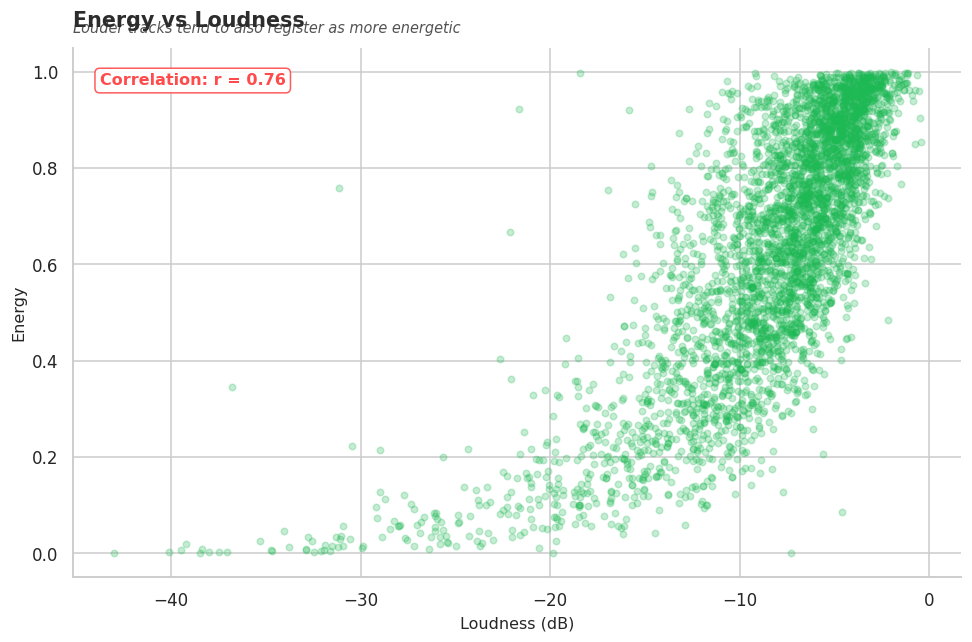

In [17]:
sample2 = df.sample(4000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(sample2["loudness"], sample2["energy"], alpha=0.25, s=18, color=SPOTIFY_GREEN)
styled_chart("Energy vs Loudness", "Louder tracks tend to also register as more energetic",
             ax=ax, xlabel="Loudness (dB)", ylabel="Energy")

corr = df["loudness"].corr(df["energy"])
ax.text(0.03, 0.93, f"Correlation: r = {corr:.2f}", transform=ax.transAxes,
        fontsize=10.5, fontweight="bold", color=HIGHLIGHT,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor=HIGHLIGHT, alpha=0.9))

plt.tight_layout()
plt.savefig("09_energy_vs_loudness.png", dpi=150, bbox_inches="tight")
plt.show()


### 10. Correlation Heatmap
The most important visual in this notebook - a bird's-eye view of how every numeric audio feature relates to every other.


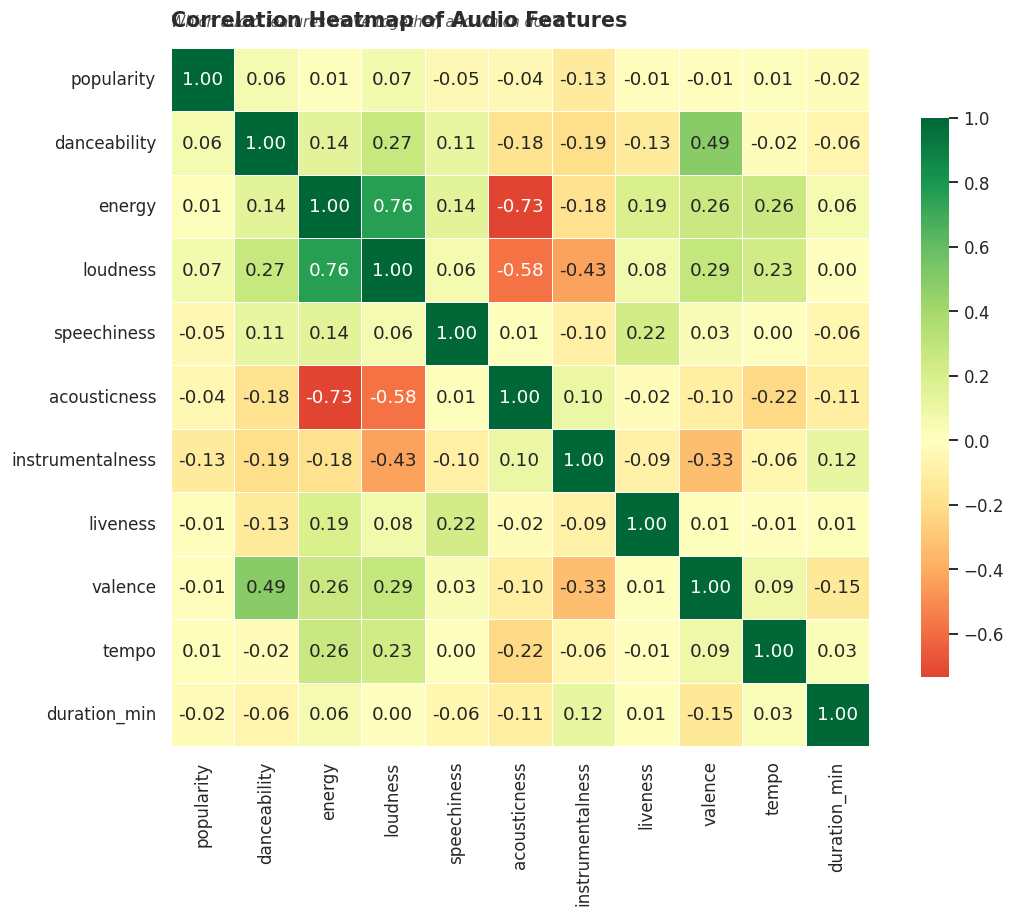

In [18]:
numeric_cols = ["popularity", "danceability", "energy", "loudness", "speechiness",
                 "acousticness", "instrumentalness", "liveness", "valence", "tempo", "duration_min"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8.5))
cmap = sns.light_palette(SPOTIFY_GREEN, as_cmap=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, square=True,
            linewidths=0.6, cbar_kws={"shrink": 0.8}, ax=ax)
styled_chart("Correlation Heatmap of Audio Features", "Which audio features move together, and which don't",
             ax=ax)

plt.tight_layout()
plt.savefig("10_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### 11. Tempo Distribution - Boxplot

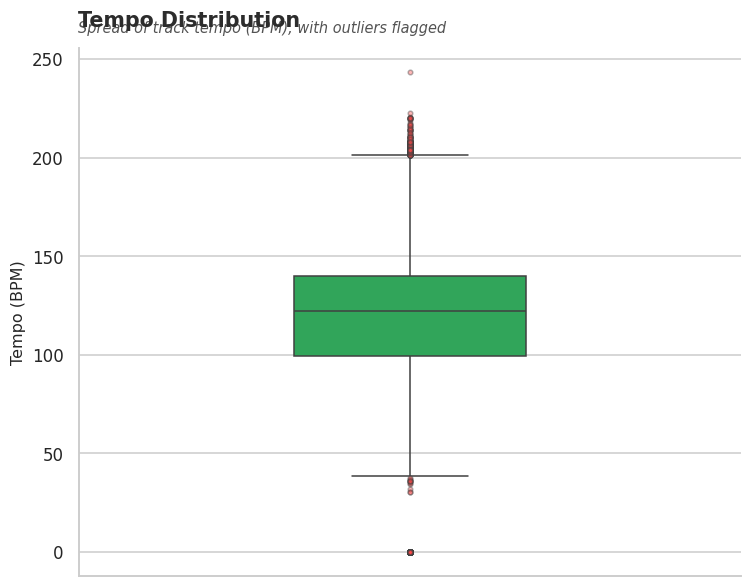

In [19]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.boxplot(y=df["tempo"], ax=ax, color=SPOTIFY_GREEN, width=0.35,
            flierprops=dict(markerfacecolor=HIGHLIGHT, markersize=3, alpha=0.4))
styled_chart("Tempo Distribution", "Spread of track tempo (BPM), with outliers flagged",
             ax=ax, ylabel="Tempo (BPM)")

plt.tight_layout()
plt.savefig("11_tempo_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


### 12. Popularity by Genre - Boxplot

/tmp/ipykernel_2670/2482219568.py:5: UserWarning:


The palette list has fewer values (6) than needed (113) and will cycle, which may produce an uninterpretable plot.



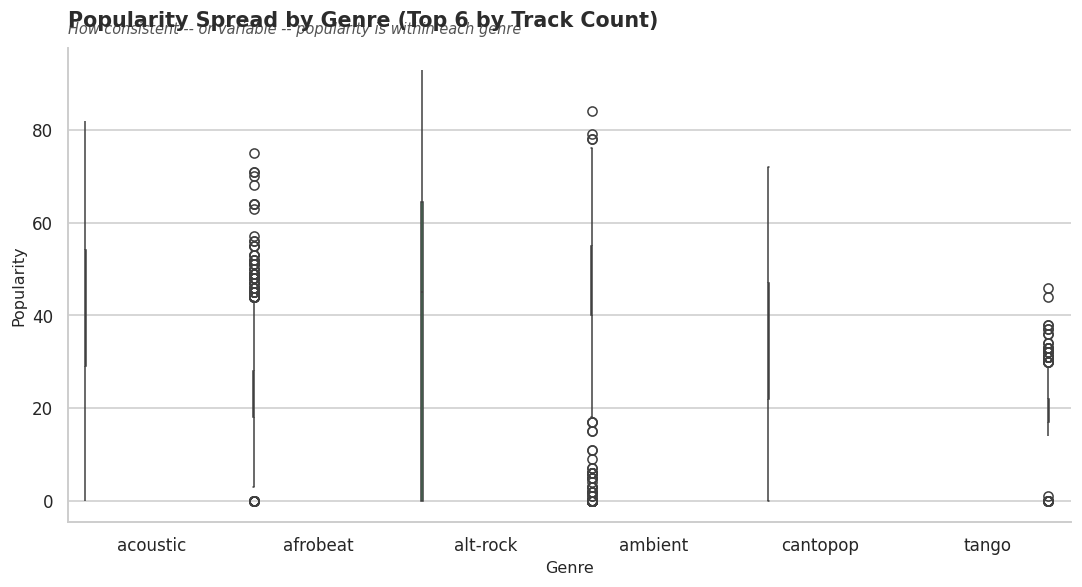

In [20]:
top6_genres = df["track_genre"].value_counts().head(6).index.tolist()
subset = df[df["track_genre"].isin(top6_genres)]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(x="track_genre", y="popularity", data=subset, hue="track_genre",
            order=top6_genres, palette=PALETTE_SEQ[:6], legend=False, ax=ax)
styled_chart("Popularity Spread by Genre (Top 6 by Track Count)",
             "How consistent -- or variable -- popularity is within each genre",
             ax=ax, xlabel="Genre", ylabel="Popularity")

plt.tight_layout()
plt.savefig("12_popularity_by_genre_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


### 13. Danceability by Genre - Violin Plot

/tmp/ipykernel_2670/4223764799.py:2: UserWarning:


The palette list has fewer values (6) than needed (113) and will cycle, which may produce an uninterpretable plot.



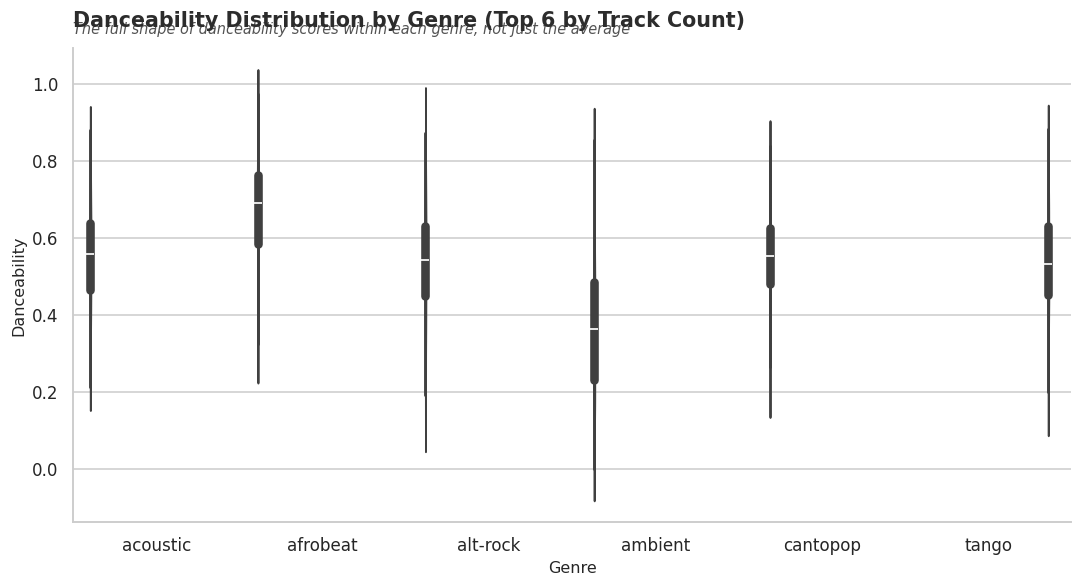

In [21]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.violinplot(x="track_genre", y="danceability", data=subset, hue="track_genre",
               order=top6_genres, palette=PALETTE_SEQ[:6], legend=False, ax=ax)
styled_chart("Danceability Distribution by Genre (Top 6 by Track Count)",
             "The full shape of danceability scores within each genre, not just the average",
             ax=ax, xlabel="Genre", ylabel="Danceability")

plt.tight_layout()
plt.savefig("13_danceability_violin.png", dpi=150, bbox_inches="tight")
plt.show()


### 14. Pairplot (Optional) - Feature Relationships at a Glance

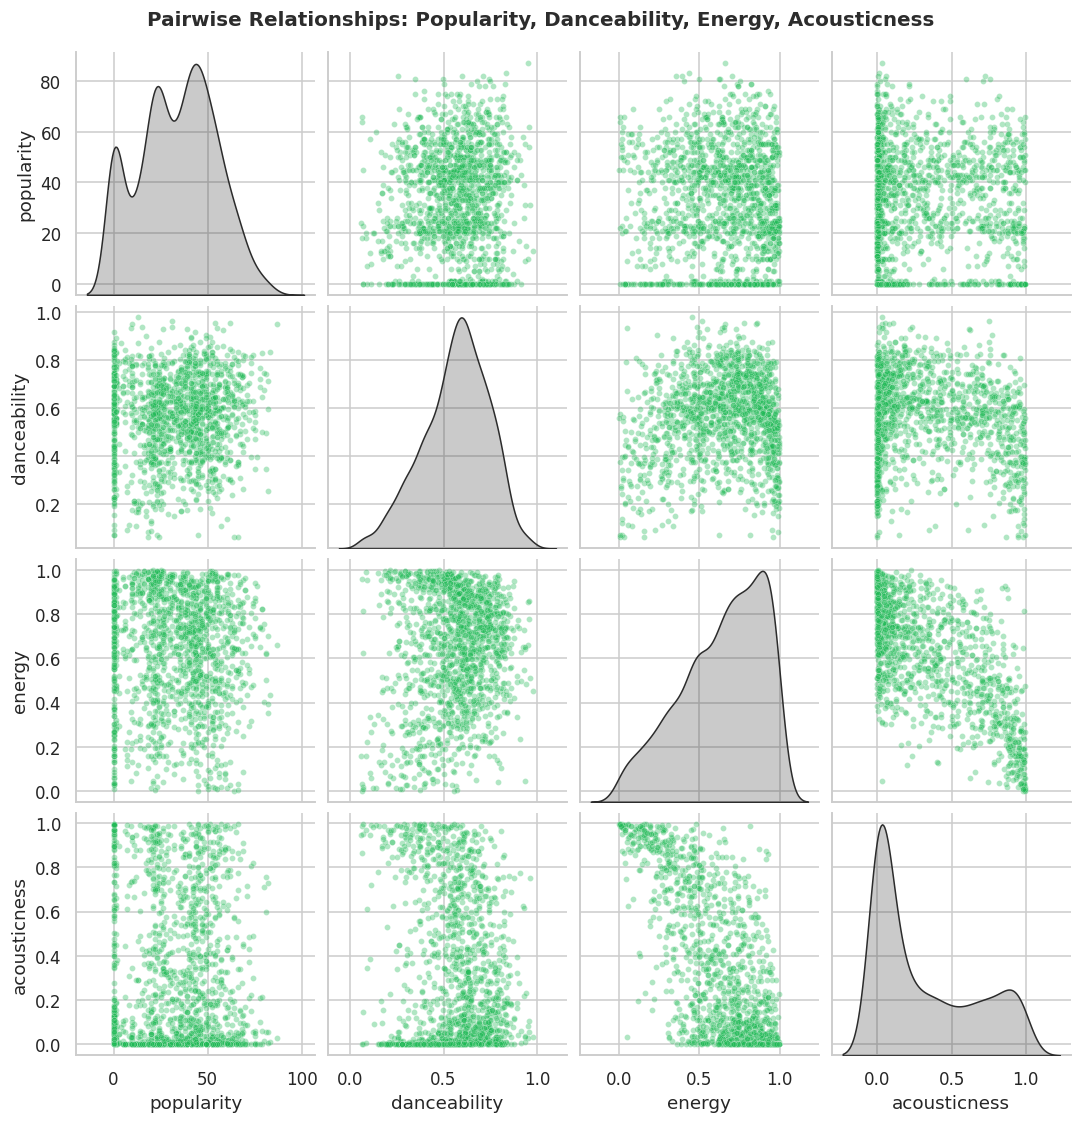

In [22]:
pair_features = ["popularity", "danceability", "energy", "acousticness"]
sample3 = df.sample(1500, random_state=42)

g = sns.pairplot(sample3[pair_features], diag_kind="kde",
                  plot_kws={"alpha": 0.35, "s": 15, "color": SPOTIFY_GREEN},
                  diag_kws={"color": SPOTIFY_DARK})
g.fig.suptitle("Pairwise Relationships: Popularity, Danceability, Energy, Acousticness",
               y=1.02, fontsize=13, fontweight="bold", color=SPOTIFY_DARK)

g.savefig("14_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Summary Dashboard

A single 3×3 view that pulls together the most important charts from this
notebook into one story - ideal for a portfolio screenshot or a quick
share with stakeholders.


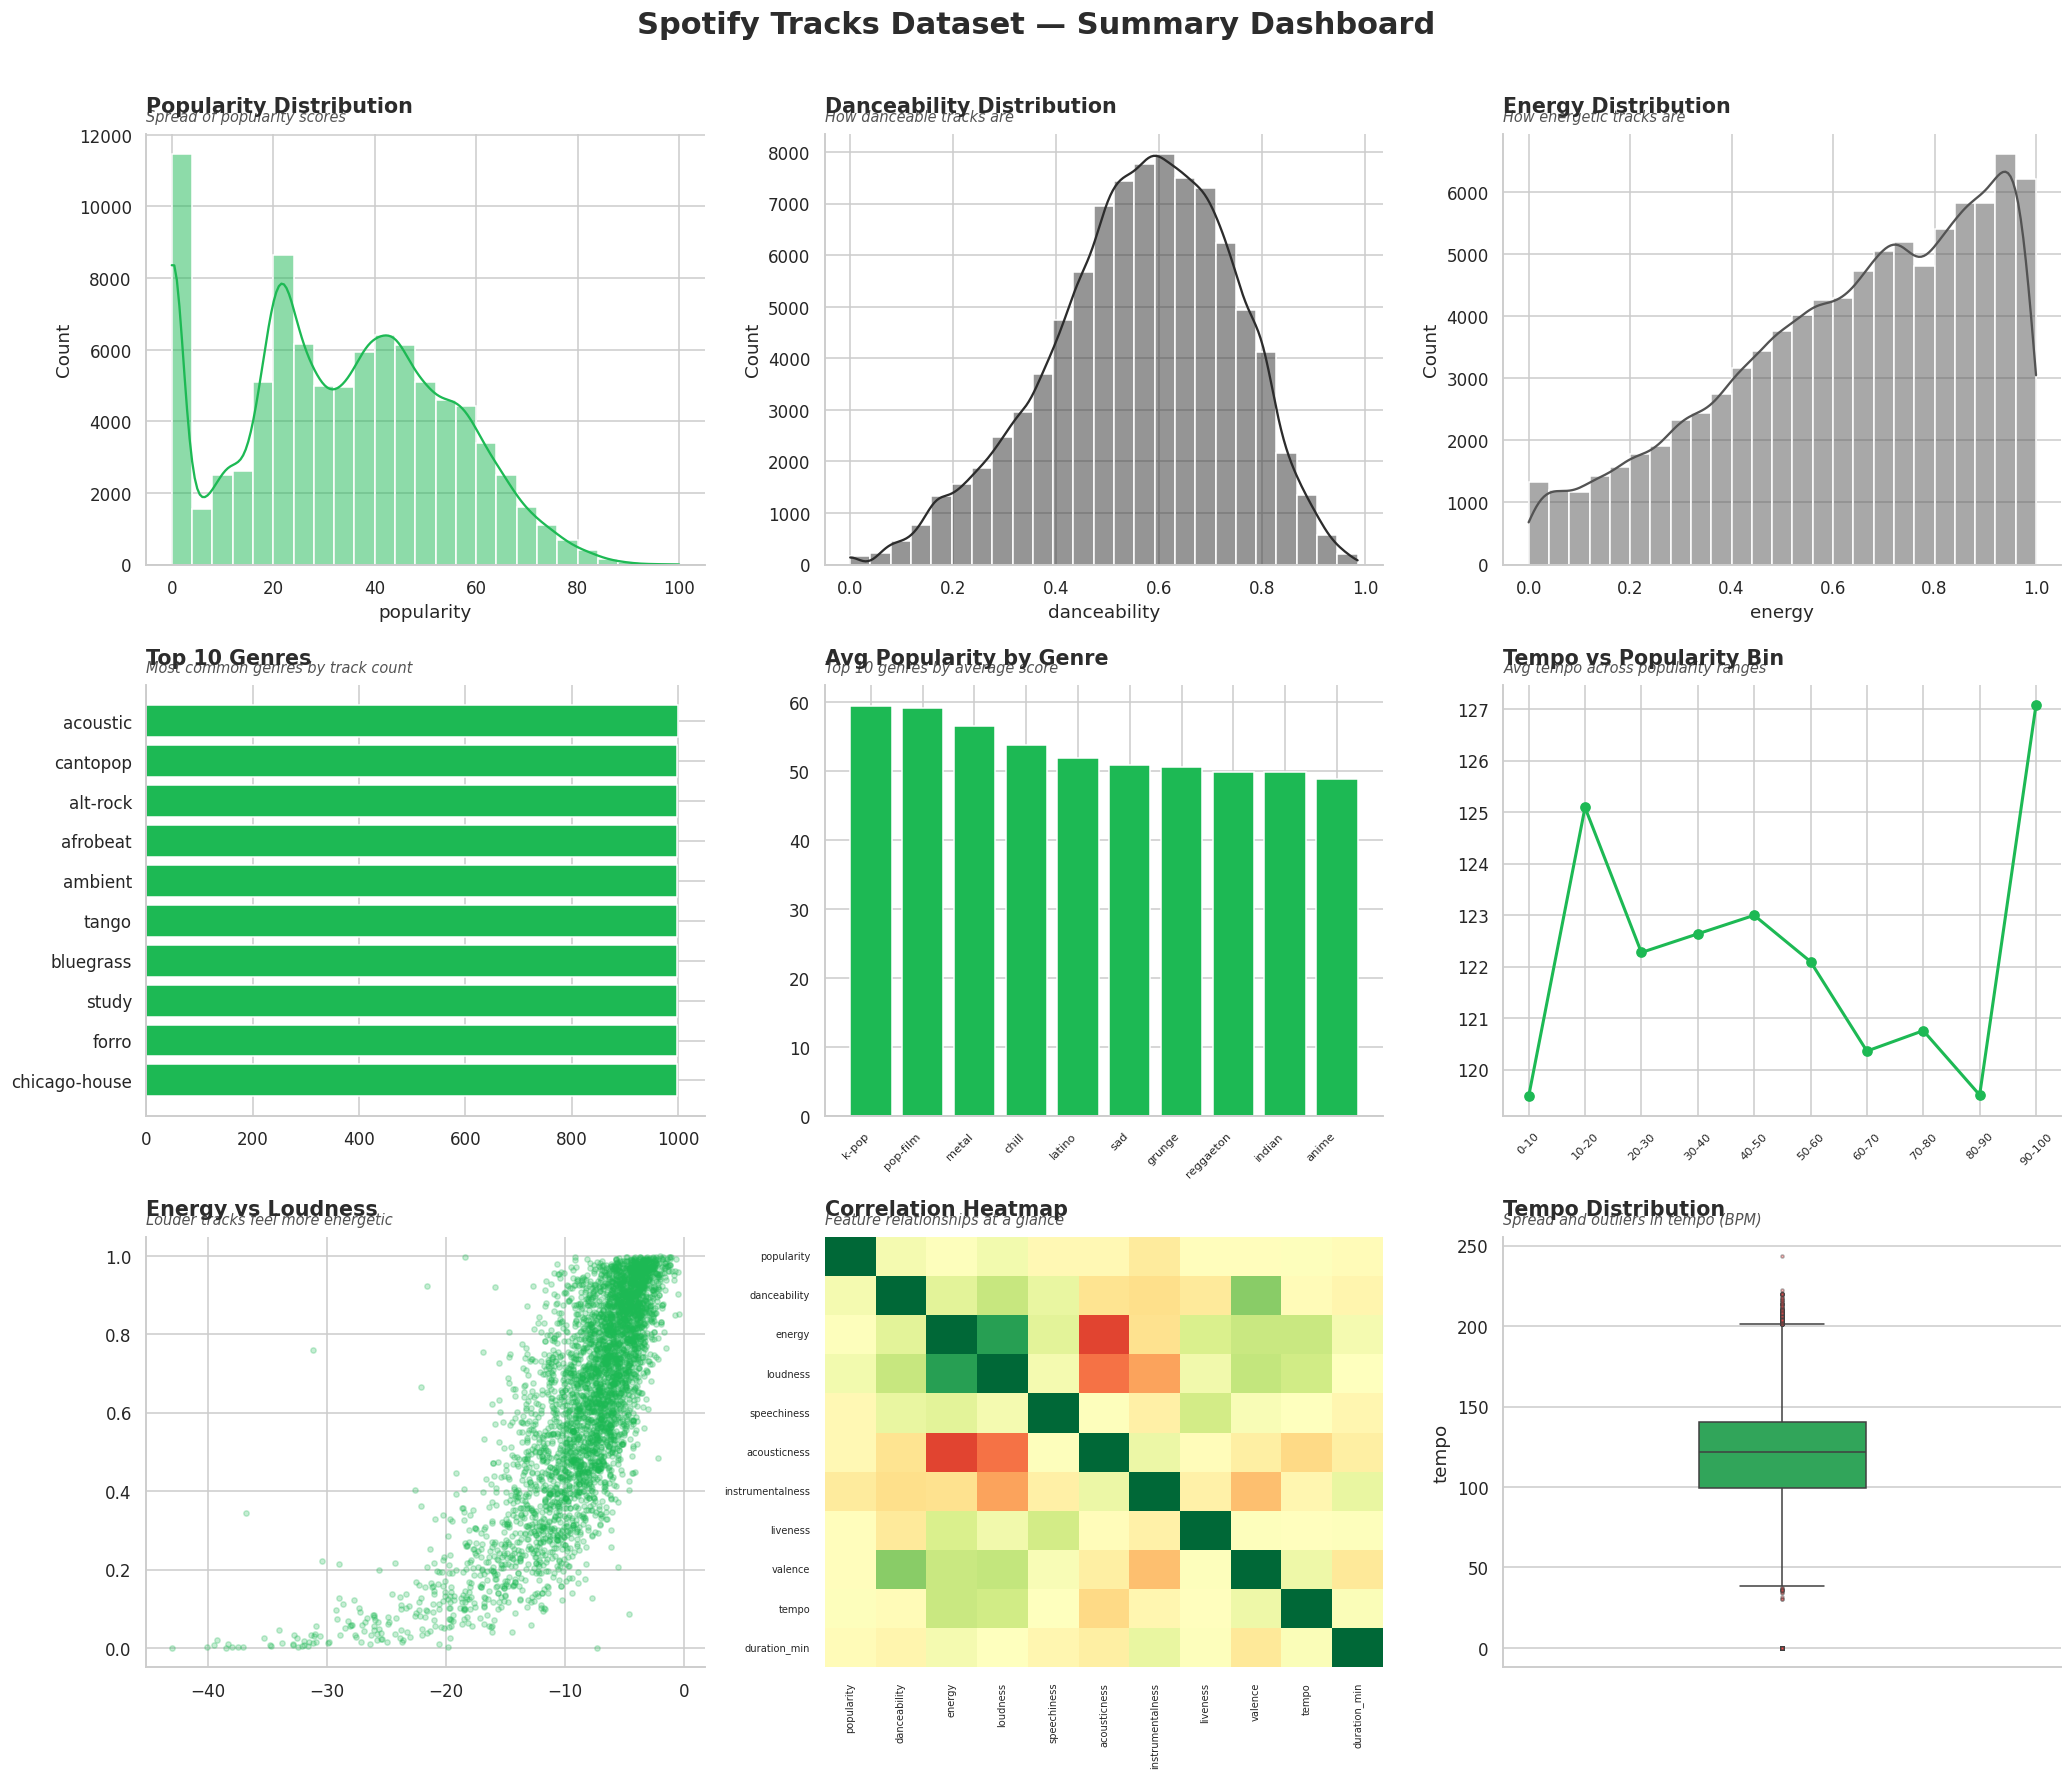

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(19, 16))
fig.suptitle("Spotify Tracks Dataset — Summary Dashboard", fontsize=20, fontweight="bold",
             color=SPOTIFY_DARK, y=1.01)

# (0,0) Popularity distribution
sns.histplot(df["popularity"], bins=25, kde=True, ax=axes[0, 0], color=SPOTIFY_GREEN)
styled_chart("Popularity Distribution", "Spread of popularity scores", ax=axes[0, 0])

# (0,1) Danceability distribution
sns.histplot(df["danceability"], bins=25, kde=True, ax=axes[0, 1], color=SPOTIFY_DARK)
styled_chart("Danceability Distribution", "How danceable tracks are", ax=axes[0, 1])

# (0,2) Energy distribution
sns.histplot(df["energy"], bins=25, kde=True, ax=axes[0, 2], color=SPOTIFY_GREY)
styled_chart("Energy Distribution", "How energetic tracks are", ax=axes[0, 2])

# (1,0) Top 10 genres
top10 = df["track_genre"].value_counts().head(10).sort_values()
axes[1, 0].barh(top10.index, top10.values, color=SPOTIFY_GREEN)
styled_chart("Top 10 Genres", "Most common genres by track count", ax=axes[1, 0])

# (1,1) Avg popularity by genre
axes[1, 1].bar(range(len(avg_pop_genre)), avg_pop_genre.values, color=SPOTIFY_GREEN)
axes[1, 1].set_xticks(range(len(avg_pop_genre)))
axes[1, 1].set_xticklabels(avg_pop_genre.index, rotation=45, ha="right", fontsize=7.5)
styled_chart("Avg Popularity by Genre", "Top 10 genres by average score", ax=axes[1, 1])

# (1,2) Tempo trend
axes[1, 2].plot(x_labels, tempo_trend.values, marker="o", color=SPOTIFY_GREEN, linewidth=2)
axes[1, 2].tick_params(axis="x", rotation=45, labelsize=7.5)
styled_chart("Tempo vs Popularity Bin", "Avg tempo across popularity ranges", ax=axes[1, 2])

# (2,0) Energy vs Loudness scatter
axes[2, 0].scatter(sample2["loudness"], sample2["energy"], alpha=0.25, s=12, color=SPOTIFY_GREEN)
styled_chart("Energy vs Loudness", "Louder tracks feel more energetic", ax=axes[2, 0])

# (2,1) Correlation heatmap (mini)
sns.heatmap(corr, cmap="RdYlGn", center=0, cbar=False, ax=axes[2, 1], annot=False)
styled_chart("Correlation Heatmap", "Feature relationships at a glance", ax=axes[2, 1])
axes[2, 1].set_xticklabels(axes[2, 1].get_xticklabels(), rotation=90, fontsize=6.5)
axes[2, 1].set_yticklabels(axes[2, 1].get_yticklabels(), rotation=0, fontsize=6.5)

# (2,2) Tempo boxplot
sns.boxplot(y=df["tempo"], ax=axes[2, 2], color=SPOTIFY_GREEN, width=0.3,
            flierprops=dict(markerfacecolor=HIGHLIGHT, markersize=2, alpha=0.4))
styled_chart("Tempo Distribution", "Spread and outliers in tempo (BPM)", ax=axes[2, 2])

plt.tight_layout()
plt.savefig("15_summary_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Insights

Danceability and Energy show a positive relationship: with each
other and both connect strongly to loudness — upbeat, energetic
production tends to go hand in hand across these features.

Some genres consistently achieve higher popularity scores - K-pop
and pop-film sit clearly above the rest in average popularity, regardless
of how many tracks each genre has.

Most tracks fall within a moderate popularity range - the
distribution isn't extreme; very few tracks sit at the highest end (70+),
reflecting music's typical long-tail popularity pattern.

Loud tracks generally tend to have higher energy values - the
energy vs loudness scatter plot and correlation heatmap both confirm a
strong positive relationship (r ≈ 0.76).

A few outliers exist in tempo and duration - the boxplots flag a
handful of tracks with unusually fast/slow tempo or unusually long/short
duration; these are kept in the dataset as legitimate edge cases (e.g.
ambient or spoken-word tracks) rather than removed as errors.

Genre "shape," not just genre averages, differs a lot - the violin
plots show that some genres (e.g. Latino) have tightly clustered
danceability scores, while others are far more spread out — the average
alone would hide that difference.
